In [3]:
pip install xgboost imbalanced-learn scapy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Cell 1 — Imports & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Load all CSV files from data folder and combine them
data_folder = '../data/MachineLearningCVE'

files = os.listdir(data_folder)
print("Files found:")
for f in files:
    print(" -", f)

# Combine all files into one dataframe
df = pd.concat([
    pd.read_csv(os.path.join(data_folder, f), encoding='utf-8', low_memory=False)
    for f in files
], ignore_index=True)

print("\nCombined shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Files found:
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv

Combined shape: (2830743, 79)

First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# Cell 2 — Dataset Inspection

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nAttack type distribution:")
print(df[' Label'].value_counts())
print("\nMissing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())

Shape: (2830743, 79)

Column names: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Co

In [6]:
# Cell 3 — Preprocessing

# Fix column names (strip leading/trailing spaces)
df.columns = df.columns.str.strip()

# Drop missing values
df = df.dropna()

# Drop infinity values (common in network flow data)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("Shape after cleaning:", df.shape)

# Check attack distribution again
print("\nAttack distribution:")
print(df['Label'].value_counts())

# Group rare attacks to avoid tiny classes
# Anything under 1000 samples gets grouped as 'Other'
attack_counts = df['Label'].value_counts()
rare = attack_counts[attack_counts < 1000].index.tolist()
print(f"\nGrouping rare attacks into 'Other': {rare}")
df['Label'] = df['Label'].apply(lambda x: 'Other' if x in rare else x)

print("\nFinal class distribution:")
print(df['Label'].value_counts())

# Encode target labels to numbers
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

print("\nLabel mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} = {label}")

Shape after cleaning: (2827876, 79)

Attack distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Grouping rare attacks into 'Other': ['Web Attack � XSS', 'Infiltration', 'Web Attack � Sql Injection', 'Heartbleed']

Final class distribution:
Label
BENIGN                      2271320
DoS Hulk                     230124
PortScan                     158804
DDoS                         128025
DoS GoldenEye                 10293
FTP-Patat

In [7]:
# Cell 4 — Sampling & Feature Preparation

# Simpler sampling approach
samples = []
for label in df['Label'].unique():
    subset = df[df['Label'] == label]
    samples.append(subset.sample(min(len(subset), 10000), random_state=42))

df_sampled = pd.concat(samples, ignore_index=True)

print("Sampled class distribution:")
print(df_sampled['Label'].value_counts())
print("\nTotal sampled rows:", len(df_sampled))

# Separate features and target
X = df_sampled.drop(columns=['Label', 'Label_encoded'])
y = df_sampled['Label_encoded']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Apply SMOTE only on training data
print("\nApplying SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE train size:", X_train_sm.shape[0])
print("After SMOTE class distribution:")
print(pd.Series(y_train_sm).value_counts())

Sampled class distribution:
Label
BENIGN                      10000
DDoS                        10000
PortScan                    10000
DoS Hulk                    10000
DoS GoldenEye               10000
FTP-Patator                  7935
SSH-Patator                  5897
DoS slowloris                5796
DoS Slowhttptest             5499
Bot                          1956
Web Attack � Brute Force     1507
Other                         720
Name: count, dtype: int64

Total sampled rows: 79310

Train size: 63448
Test size: 15862

Applying SMOTE...
After SMOTE train size: 96000
After SMOTE class distribution:
Label_encoded
9     8000
7     8000
4     8000
8     8000
5     8000
6     8000
10    8000
0     8000
11    8000
3     8000
2     8000
1     8000
Name: count, dtype: int64


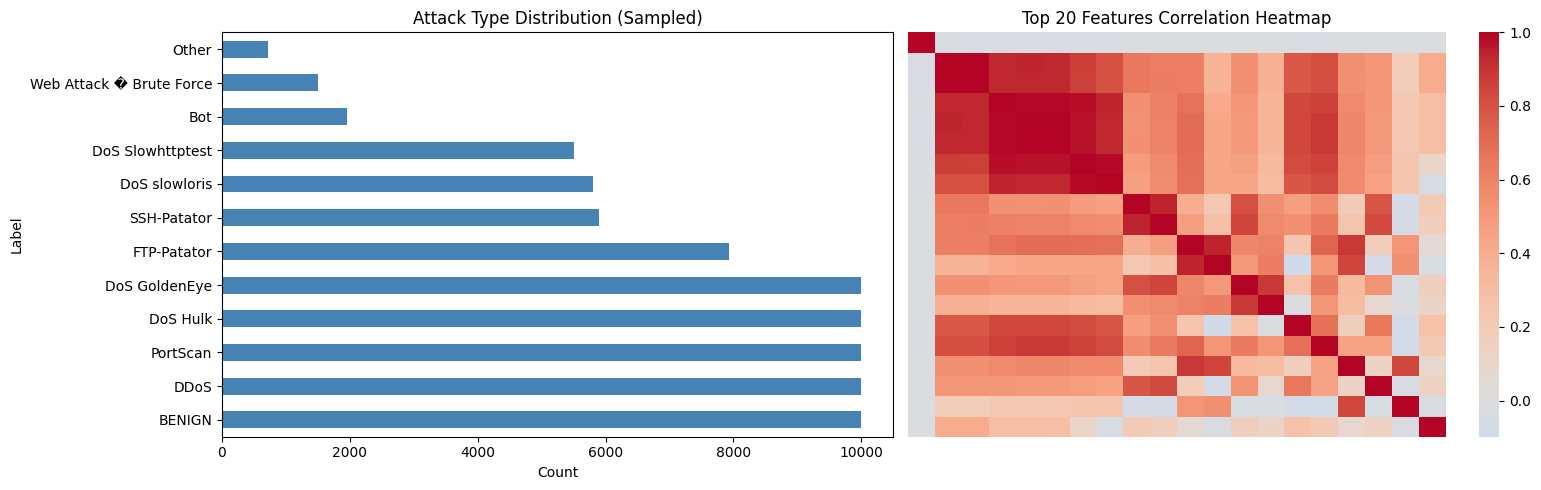

Before SMOTE - Train class counts:
Label_encoded
9     8000
4     8000
0     8000
3     8000
2     8000
7     6348
10    4717
6     4637
5     4399
1     1565
11    1206
8      576
Name: count, dtype: int64

After SMOTE - Train class counts:
Label_encoded
9     8000
7     8000
4     8000
8     8000
5     8000
6     8000
10    8000
0     8000
11    8000
3     8000
2     8000
1     8000
Name: count, dtype: int64


In [8]:
# Cell 5 — EDA

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Attack type distribution (sampled)
df_sampled['Label'].value_counts().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Attack Type Distribution (Sampled)')
axes[0].set_xlabel('Count')

# Plot 2 — Correlation heatmap (top 20 features only for readability)
top_features = df_sampled.drop(columns=['Label', 'Label_encoded']).var().nlargest(20).index
corr = df_sampled[top_features].corr()
sns.heatmap(corr, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title('Top 20 Features Correlation Heatmap')

plt.tight_layout()
plt.show()

# Print class balance before and after SMOTE
print("Before SMOTE - Train class counts:")
print(pd.Series(y_train).value_counts())
print("\nAfter SMOTE - Train class counts:")
print(pd.Series(y_train_sm).value_counts())

In [9]:
# Cell 6 — Model Training

# Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

# XGBoost
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           n_jobs=-1, verbosity=0,
                           eval_metric='mlogloss')
xgb_model.fit(X_train_sm, y_train_sm)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Accuracy:       {xgb_acc*100:.2f}%")

# Comparison
print("\n--- Model Comparison ---")
print(f"Random Forest: {rf_acc*100:.2f}%")
print(f"XGBoost:       {xgb_acc*100:.2f}%")

Training Random Forest...
Random Forest Accuracy: 98.76%

Training XGBoost...
XGBoost Accuracy:       98.81%

--- Model Comparison ---
Random Forest: 98.76%
XGBoost:       98.81%


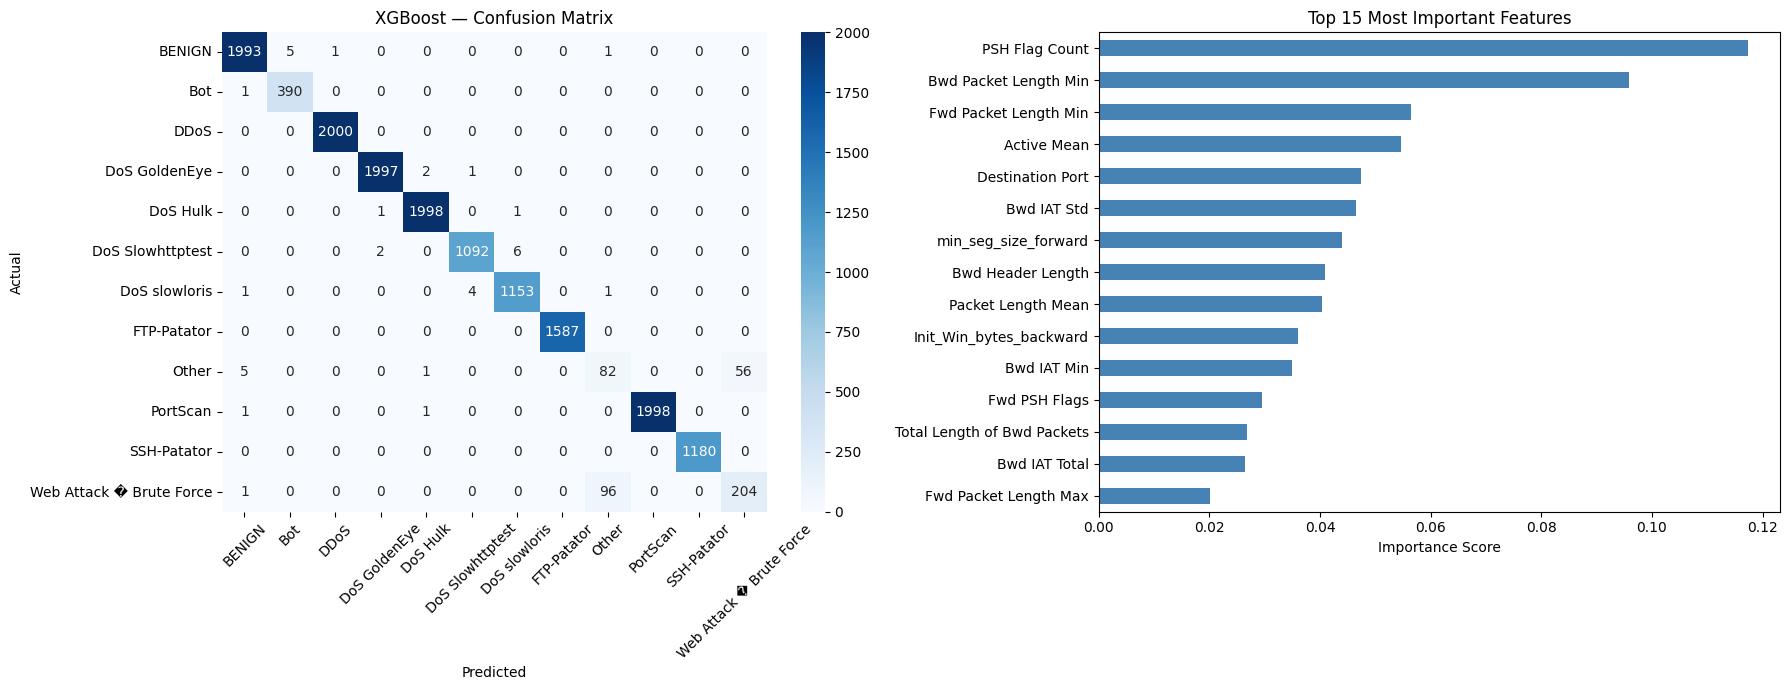


Classification Report — XGBoost:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00      2000
                     Bot       0.99      1.00      0.99       391
                    DDoS       1.00      1.00      1.00      2000
           DoS GoldenEye       1.00      1.00      1.00      2000
                DoS Hulk       1.00      1.00      1.00      2000
        DoS Slowhttptest       1.00      0.99      0.99      1100
           DoS slowloris       0.99      0.99      0.99      1159
             FTP-Patator       1.00      1.00      1.00      1587
                   Other       0.46      0.57      0.51       144
                PortScan       1.00      1.00      1.00      2000
             SSH-Patator       1.00      1.00      1.00      1180
Web Attack � Brute Force       0.78      0.68      0.73       301

                accuracy                           0.99     15862
               macro avg       0.93     

In [10]:
# Cell 7 — Evaluation

# Get label names for readable output
label_names = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion Matrix — XGBoost (better model)
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names,
            ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Feature Importance — XGBoost
importances = pd.Series(xgb_model.feature_importances_,
                        index=df_sampled.drop(columns=['Label','Label_encoded']).columns)
importances.sort_values().tail(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Most Important Features')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Per-attack classification report
print("\nClassification Report — XGBoost:")
print(classification_report(y_test, xgb_preds, target_names=label_names))

In [11]:
# Cell 9 — Save model, scaler and encoder

import joblib
import os

save_path = '../notebooks/'

joblib.dump(xgb_model, save_path + 'xgb_model.pkl')
joblib.dump(scaler, save_path + 'scaler.pkl')
joblib.dump(le, save_path + 'label_encoder.pkl')
joblib.dump(list(df_sampled.drop(columns=['Label','Label_encoded']).columns),
            save_path + 'feature_cols.pkl')

print("Models saved successfully!")
print("Files saved:", os.listdir(save_path))

Models saved successfully!
Files saved: ['feature_cols.pkl', 'label_encoder.pkl', 'live_capture.py', 'nids.ipynb', 'scaler.pkl', 'xgb_model.pkl']
